# Testing Different Probes on Simple Data

In [21]:
# IMPORTS
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import random
import json
import copy
import configparser
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.linear_model._logistic")

# Numerical / ML
import torch as t
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression   # for LASSO
from sklearn.preprocessing import StandardScaler      # scale features for fair L1 penalty
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier                     # tree-based probe for nonlinearity

# Project modules (in repo root)
from utils import DataManager
from probes import LRProbe

# --- Reproducibility (CS229: same seed → same train/test split and model init) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
t.manual_seed(SEED)

print(f"PyTorch {t.__version__}  |  CUDA available: {t.cuda.is_available()}")

PyTorch 2.10.0  |  CUDA available: False


In [22]:
# CONFIG

model = 'llama-2-13b'
config = configparser.ConfigParser()
config.read('../config.ini')
probe_layer = 12
noperiod = config[model].get('noperiod', 'False').strip().lower() == 'true'

split = 0.8   # 80% train, 20% test
device = 'cuda:0' if t.cuda.is_available() else 'cpu'

# All datasets we'll train and evaluate on (and use for OOD: train on one, test on another)
all_datasets = [
    'cities', 'neg_cities',
    'larger_than', 'smaller_than',
    'sp_en_trans', 'neg_sp_en_trans',
]

print(f"Model: {model}  |  Layer: {probe_layer}  |  Split: {split}  |  Seed: {SEED}")

Model: llama-2-13b  |  Layer: 12  |  Split: 0.8  |  Seed: 42


In [23]:
# LOAD ACTS
# For each dataset we load precomputed activations from the LLM (one vector per statement),
# split into train (80%) and test (20%) with a fixed seed for reprod. 

# We store both numpy arrays (for sklearn/XGBoost) and torch tensors (for LRProbe and MLP).
# data[ds] = (train_X_np, train_y_np, test_X_np, test_y_np, train_X_t, train_y_t, test_X_t, test_y_t)

data = {}

for ds in all_datasets:
    dm = DataManager()
    dm.add_dataset(ds, model, probe_layer, split=split, seed=SEED,
                   noperiod=noperiod, center=True, device=device)
    tr_acts, tr_labels = dm.data['train'][ds]
    te_acts, te_labels = dm.data['val'][ds]   # we use 'val' as our test set

    data[ds] = (
        tr_acts.cpu().numpy(), tr_labels.cpu().numpy().astype(int),
        te_acts.cpu().numpy(), te_labels.cpu().numpy().astype(int),
        tr_acts, tr_labels, te_acts, te_labels,
    )
    print(f"{ds:20s}  train: {tr_acts.shape}  test: {te_acts.shape}")

cities                train: torch.Size([1196, 5120])  test: torch.Size([300, 5120])
neg_cities            train: torch.Size([1196, 5120])  test: torch.Size([300, 5120])
larger_than           train: torch.Size([1584, 5120])  test: torch.Size([396, 5120])
smaller_than          train: torch.Size([1584, 5120])  test: torch.Size([396, 5120])
sp_en_trans           train: torch.Size([283, 5120])  test: torch.Size([71, 5120])
neg_sp_en_trans       train: torch.Size([283, 5120])  test: torch.Size([71, 5120])


In [24]:
# HELPERS
# Every probe outputs a probability P(true). Two metrics:
#   - Accuracy: fraction correct when we predict true if prob >= 0.5 
#   - AUROC: area under ROC curve; threshold doesn't matter

def evaluate(y_true, y_prob):
    """
    Args:
        y_true: (N,) array of 0/1 labels (ground truth).
        y_prob: (N,) array of predicted probabilities in [0, 1].
    Returns:
        dict with 'accuracy' and 'auroc'.
    """
    y_pred = (np.asarray(y_prob) >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auroc = float('nan')  # e.g. only one class in y_true
    return {'accuracy': acc, 'auroc': auroc}

---
## 1. Baseline LRProbe

In [25]:
# For each dataset: fit one linear probe (LRProbe) on train, evaluate on train and test.

baseline_results = {}  # {dataset: {'train': {acc, auroc}, 'test': {acc, auroc}}}

print(f"{'Dataset':20s}  {'Train Acc':>10s}  {'Test Acc':>10s}  {'Test AUROC':>10s}")
print('=' * 60)

for ds in all_datasets:
    tr_X_np, tr_y_np, te_X_np, te_y_np, tr_X_t, tr_y_t, te_X_t, te_y_t = data[ds]

    # LRProbe = linear layer + BCE; .from_data() fits it on the given train set
    probe = LRProbe.from_data(tr_X_t, tr_y_t, device=device)

    # Predict probabilities (no gradient needed for evaluation)
    with t.no_grad():
        tr_prob = probe(tr_X_t).cpu().numpy()
        te_prob = probe(te_X_t).cpu().numpy()

    tr_eval = evaluate(tr_y_np, tr_prob)
    te_eval = evaluate(te_y_np, te_prob)

    baseline_results[ds] = {'train': tr_eval, 'test': te_eval}
    print(f"{ds:20s}  {tr_eval['accuracy']:10.4f}  {te_eval['accuracy']:10.4f}  {te_eval['auroc']:10.4f}")

print('\nThese should match baseline.ipynb in_distribution results.')

Dataset                Train Acc    Test Acc  Test AUROC
cities                    0.9975      0.9933      0.9999
neg_cities                0.9983      0.9967      1.0000
larger_than               1.0000      1.0000      1.0000
smaller_than              1.0000      0.9975      1.0000
sp_en_trans               1.0000      1.0000      1.0000
neg_sp_en_trans           1.0000      1.0000      1.0000

These should match baseline.ipynb in_distribution results.


---
## 2. XGBoost diagnostic for nonlinearity

In [26]:
# Train one XGBoost classifier per dataset (same train/test split as elsewhere)
# - max_depth=4: allow some nonlinearity without overfitting
# - n_estimators=200, learning_rate=0.1: standard choices

xgb_results = {}
xgb_importances = {}  # {dataset: array of feature importances}

print(f"{'Dataset':20s}  {'Train Acc':>10s}  {'Test Acc':>10s}  {'Test AUROC':>10s}")
print('=' * 60)

for ds in all_datasets:
    tr_X, tr_y, te_X, te_y = data[ds][:4]

    clf = XGBClassifier(
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=SEED,
        verbosity=0,
        n_jobs=1,
        tree_method='hist',
    )
    clf.fit(tr_X, tr_y)

    tr_prob = clf.predict_proba(tr_X)[:, 1]
    te_prob = clf.predict_proba(te_X)[:, 1]

    tr_eval = evaluate(tr_y, tr_prob)
    te_eval = evaluate(te_y, te_prob)
    xgb_results[ds] = {'train': tr_eval, 'test': te_eval}

    print(f"{ds:20s}  {tr_eval['accuracy']:10.4f}  {te_eval['accuracy']:10.4f}  {te_eval['auroc']:10.4f}")

Dataset                Train Acc    Test Acc  Test AUROC
cities                    1.0000      0.9967      0.9993
neg_cities                1.0000      0.9867      0.9998
larger_than               1.0000      0.9975      1.0000
smaller_than              1.0000      0.9975      0.9999
sp_en_trans               1.0000      0.9859      1.0000
neg_sp_en_trans           1.0000      0.9859      1.0000


---
## 3. Two-layer MLP probe

In [27]:
# Architecture: input -> linear -> ReLU -> Linear

class MLPProbe(t.nn.Module):
    """
    Two-layer MLP: Linear(d, h) -> ReLU -> Linear(h, 1).
    Outputs raw logits (no sigmoid) during training.
    """
    def __init__(self, d_in, hidden):
        super().__init__()
        self.net = t.nn.Sequential(
            t.nn.Linear(d_in, hidden),
            t.nn.ReLU(),
            t.nn.Linear(hidden, 1),
        )

    def forward(self, x):
        """Returns raw logits (N,)"""
        return self.net(x).squeeze(-1)

    def predict_proba(self, x):
        """Returns probabilities (N,) in [0,1]"""
        with t.no_grad():
            return t.sigmoid(self.forward(x))


def train_mlp(train_X, train_y, val_X, val_y,
              hidden=64, lr=1e-3, weight_decay=0.1,
              epochs=500, patience=30, device='cpu'):
    """
    Train MLPProbe with early stopping on validation loss.

    Returns:
        best_model: MLPProbe with lowest val loss
        history: dict with 'train_loss' and 'val_loss' lists
    """
    d_in = train_X.shape[1]
    model = MLPProbe(d_in, hidden).to(device)
    opt = t.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = t.nn.BCEWithLogitsLoss()

    train_X = train_X.to(device)
    train_y = train_y.to(device)
    val_X = val_X.to(device)
    val_y = val_y.to(device)

    best_val_loss = float('inf')
    best_state = None
    wait = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        opt.zero_grad()
        logits = model(train_X)
        loss = criterion(logits, train_y)
        loss.backward()
        opt.step()
        history['train_loss'].append(loss.item())

        # Val
        model.eval()
        with t.no_grad():
            val_logits = model(val_X)
            val_loss = criterion(val_logits, val_y).item()
        history['val_loss'].append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    return model, history

In [ ]:
# Train MLP on each dataset

hidden_sizes = [32, 64, 128, 256]

mlp_results = {}
mlp_histories = {}  # for loss curves

print(f"{'Dataset':20s}  {'h':>4s}  {'Train Acc':>10s}  {'Test Acc':>10s}  {'Test AUROC':>10s}")
print('=' * 65)

for ds in all_datasets:
    _, _, _, _, tr_X_t, tr_y_t, te_X_t, te_y_t = data[ds]
    tr_y_np, te_y_np = data[ds][1], data[ds][3]

    # Hold out 20% of the training split for validation
    n_tr = len(tr_X_t)
    perm = t.randperm(n_tr)
    n_val = max(1, n_tr // 5)
    val_idx, sub_tr_idx = perm[:n_val], perm[n_val:]

    best_val_auroc = -1
    best_h = None

    for h in hidden_sizes:
        t.manual_seed(SEED)
        mlp, hist = train_mlp(
            tr_X_t[sub_tr_idx], tr_y_t[sub_tr_idx],
            tr_X_t[val_idx], tr_y_t[val_idx],
            hidden=h, lr=1e-3, weight_decay=0.1,
            epochs=500, patience=30, device=device,
        )

        val_prob = mlp.predict_proba(tr_X_t[val_idx]).cpu().numpy()
        val_eval = evaluate(tr_y_t[val_idx].cpu().numpy(), val_prob)

        if val_eval['auroc'] > best_val_auroc:
            best_val_auroc = val_eval['auroc']
            best_h = h
            best_mlp = mlp
            best_hist = hist

    # Final eval with best hidden size selected on validation only
    tr_prob = best_mlp.predict_proba(tr_X_t).cpu().numpy()
    te_prob = best_mlp.predict_proba(te_X_t).cpu().numpy()
    tr_eval = evaluate(tr_y_np, tr_prob)
    te_eval = evaluate(te_y_np, te_prob)

    mlp_results[ds] = {'train': tr_eval, 'test': te_eval, 'hidden': best_h}
    mlp_histories[ds] = best_hist

    print(f"{ds:20s}  {best_h:4d}  {tr_eval['accuracy']:10.4f}  {te_eval['accuracy']:10.4f}  {te_eval['auroc']:10.4f}")

Dataset                  h   Train Acc    Test Acc  Test AUROC
cities                  32      0.9992      0.9933      1.0000
neg_cities              32      0.9992      0.9967      0.9999
larger_than             32      1.0000      0.9975      1.0000
smaller_than            32      1.0000      1.0000      1.0000
sp_en_trans             32      0.9965      1.0000      1.0000
neg_sp_en_trans         32      0.9894      1.0000      1.0000


---
## 4. LASSO logistic regression

In [29]:
# Logistic regression with L1 penalty
# The number of nonzero coefficients (NNZ)is indicative of dimensions the "truth direction" effectively uses
# Choose the regularization strength C by validation AUROC

from sklearn.model_selection import train_test_split

C_values = [0.001, 0.01, 0.1, 1.0, 10.0]   # smaller C = stronger regularization = sparser

lasso_results = {}
lasso_models = {}

print(f"{'Dataset':20s}  {'C':>6s}  {'Train Acc':>10s}  {'Test Acc':>10s}  {'Test AUROC':>10s}  {'NNZ':>5s}")
print('=' * 72)

for ds in all_datasets:
    tr_X, tr_y, te_X, te_y = data[ds][:4]

    # Standardize: fit on train only, then transform train and test (no test leakage)
    scaler = StandardScaler().fit(tr_X)
    tr_X_s = scaler.transform(tr_X)
    te_X_s = scaler.transform(te_X)

    # Split train into train/val so we can pick C by validation performance
    tr_X_sub, val_X_s, tr_y_sub, val_y = train_test_split(
        tr_X_s, tr_y, test_size=0.2, random_state=SEED, stratify=tr_y
    )

    best_val_auroc = -1
    best_C = None

    for C in C_values:
        clf = LogisticRegression(
            solver='liblinear', penalty='l1', C=C,
            max_iter=2000, random_state=SEED,
        )
        clf.fit(tr_X_sub, tr_y_sub)
        val_prob = clf.predict_proba(val_X_s)[:, 1]
        val_auc = roc_auc_score(val_y, val_prob) if len(np.unique(val_y)) > 1 else 0.0
        if val_auc > best_val_auroc:
            best_val_auroc = val_auc
            best_C = C

    # Refit best C on full training set
    final_clf = LogisticRegression(
        solver='liblinear', penalty='l1', C=best_C,
        max_iter=2000, random_state=SEED,
    )
    final_clf.fit(tr_X_s, tr_y)

    tr_prob = final_clf.predict_proba(tr_X_s)[:, 1]
    te_prob = final_clf.predict_proba(te_X_s)[:, 1]
    tr_eval = evaluate(tr_y, tr_prob)
    te_eval = evaluate(te_y, te_prob)
    nnz = int(np.sum(final_clf.coef_[0] != 0))

    lasso_results[ds] = {
        'train': tr_eval, 'test': te_eval,
        'C': best_C, 'nnz': nnz,
        'total_features': tr_X.shape[1],
    }
    lasso_models[ds] = (final_clf, scaler)

    print(f"{ds:20s}  {best_C:6.3f}  {tr_eval['accuracy']:10.4f}  {te_eval['accuracy']:10.4f}  {te_eval['auroc']:10.4f}  {nnz:5d}")

Dataset                    C   Train Acc    Test Acc  Test AUROC    NNZ
cities                 0.010      0.9950      0.9933      0.9994     28
neg_cities             0.010      0.9950      0.9933      1.0000     30
larger_than            0.010      1.0000      0.9975      1.0000     27
smaller_than           0.010      1.0000      1.0000      1.0000     30
sp_en_trans            0.100      1.0000      1.0000      1.0000     40
neg_sp_en_trans        0.100      1.0000      1.0000      1.0000     49


---
## 5. Comparative results

In [30]:
# Table of all results

probe_names = ['LRProbe (baseline)', 'XGBoost', '2-layer MLP', 'LASSO']
all_results = [baseline_results, xgb_results, mlp_results, lasso_results]

# Build table rows: for each dataset and each probe, record metrics
rows = []
for ds in all_datasets:
    for pname, pres in zip(probe_names, all_results):
        r = pres[ds]
        row = {
            'dataset': ds,
            'probe': pname,
            'train_acc': r['train']['accuracy'],
            'test_acc': r['test']['accuracy'],
            'test_auroc': r['test']['auroc'],
            'nnz': r.get('nnz', '-'),
        }
        rows.append(row)

# Print
header = f"{'Dataset':20s}  {'Probe':22s}  {'Tr Acc':>7s}  {'Te Acc':>7s}  {'AUROC':>7s}  {'NNZ':>6s}"
print(header)
print('=' * len(header))
prev_ds = None
for row in rows:
    if row['dataset'] != prev_ds:
        if prev_ds is not None:
            print('-' * len(header))
        prev_ds = row['dataset']
    nnz_str = f"{row['nnz']:>6d}" if isinstance(row['nnz'], int) else f"{row['nnz']:>6s}"
    print(f"{row['dataset']:20s}  {row['probe']:22s}  {row['train_acc']:7.4f}  {row['test_acc']:7.4f}  {row['test_auroc']:7.4f}  {nnz_str}")

Dataset               Probe                    Tr Acc   Te Acc    AUROC     NNZ
cities                LRProbe (baseline)       0.9975   0.9933   0.9999       -
cities                XGBoost                  1.0000   0.9967   0.9993       -
cities                2-layer MLP              0.9992   0.9933   1.0000       -
cities                LASSO                    0.9950   0.9933   0.9994      28
-------------------------------------------------------------------------------
neg_cities            LRProbe (baseline)       0.9983   0.9967   1.0000       -
neg_cities            XGBoost                  1.0000   0.9867   0.9998       -
neg_cities            2-layer MLP              0.9992   0.9967   0.9999       -
neg_cities            LASSO                    0.9950   0.9933   1.0000      30
-------------------------------------------------------------------------------
larger_than           LRProbe (baseline)       1.0000   1.0000   1.0000       -
larger_than           XGBoost           

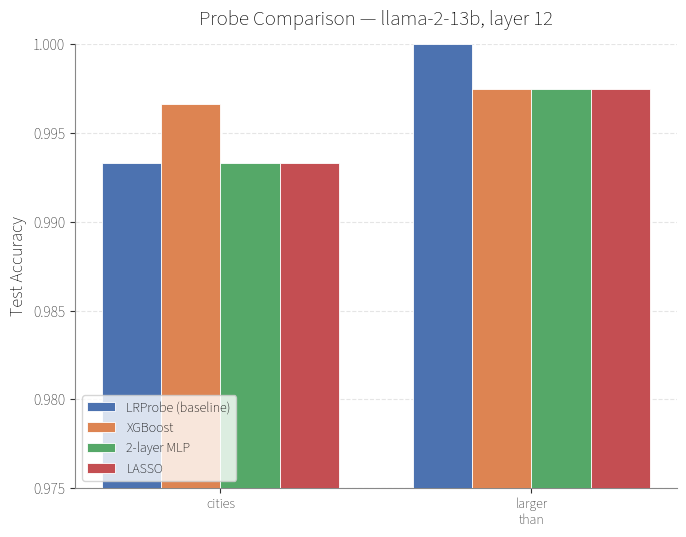

In [31]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': [
        'Source Sans Pro', 'Source Sans 3',
        'Helvetica Neue', 'Helvetica', 'Arial', 'sans-serif',
    ],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
})

plot_datasets = ['cities', 'larger_than']

fig, ax = plt.subplots(figsize=(7, 5.5))

x = np.arange(len(plot_datasets))
width = 0.19
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (pname, pres) in enumerate(zip(probe_names, all_results)):
    test_accs = [pres[ds]['test']['accuracy'] for ds in plot_datasets]
    ax.bar(x + i * width, test_accs, width, label=pname,
           color=palette[i], edgecolor='white', linewidth=0.6, zorder=3)

ax.set_ylabel('Test Accuracy', fontweight='medium')
ax.set_title(f'Probe Comparison — {model}, layer {probe_layer}',
             fontweight='bold', pad=14)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([d.replace('_', '\n') for d in plot_datasets], fontsize=10)

ax.legend(fontsize=10, frameon=True, fancybox=True,
          edgecolor='#cccccc', loc='lower left')

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color('#888888')

ax.tick_params(axis='both', colors='#333333')
ax.grid(axis='y', alpha=0.25, color='#999999', linestyle='--', zorder=0)
ax.set_ylim(0.975, 1.00)

plt.tight_layout()
plt.show()

---
## 7. OOD generalization

In [32]:
# Build matrices of OOD accuracy
# For each source dataset, train one model per probe type on that source's training set
# Test on every target's test set

n = len(all_datasets)

lr_ood_acc = np.zeros((n, n), dtype=float)
lasso_ood_acc = np.zeros((n, n), dtype=float)
xgb_ood_acc = np.zeros((n, n), dtype=float)
mlp_ood_acc = np.zeros((n, n), dtype=float)

for i, src in enumerate(all_datasets):
    print(f"Training source: {src}")

    # ------------------------------
    # LRProbe model (source-trained)
    # ------------------------------
    src_tr_X_t = data[src][4]
    src_tr_y_t = data[src][5]
    lr_probe = LRProbe.from_data(src_tr_X_t, src_tr_y_t, device=device)

    # ------------------------------
    # LASSO model (source-trained)
    # ------------------------------
    src_tr_X_np = data[src][0]
    src_tr_y_np = data[src][1]
    src_best_C = lasso_results[src]['C']

    lasso_scaler = StandardScaler().fit(src_tr_X_np)
    src_tr_X_s = lasso_scaler.transform(src_tr_X_np)

    lasso_clf = LogisticRegression(
        solver='liblinear', penalty='l1', C=src_best_C,
        max_iter=2000, random_state=SEED,
    )
    lasso_clf.fit(src_tr_X_s, src_tr_y_np)

    # ------------------------------
    # XGBoost model (source-trained)
    # ------------------------------
    xgb_clf = XGBClassifier(
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=SEED,
        verbosity=0,
        n_jobs=1,
        tree_method='hist',
    )
    xgb_clf.fit(src_tr_X_np, src_tr_y_np)

    # ------------------------------
    # MLP model (source-trained)
    # ------------------------------
    src_te_X_t = data[src][6]
    src_te_y_t = data[src][7]
    src_hidden = mlp_results[src]['hidden']

    mlp_model, _ = train_mlp(
        src_tr_X_t, src_tr_y_t, src_te_X_t, src_te_y_t,
        hidden=src_hidden, device=device,
    )
    mlp_model.eval()

    # ------------------------------
    # Evaluate all target test sets
    # ------------------------------
    for j, tgt in enumerate(all_datasets):
        tgt_te_X_np = data[tgt][2]
        tgt_te_y_np = data[tgt][3]
        tgt_te_X_t = data[tgt][6]

        # LRProbe
        with t.no_grad():
            lr_prob = lr_probe(tgt_te_X_t).cpu().numpy()
        lr_ood_acc[i, j] = evaluate(tgt_te_y_np, lr_prob)['accuracy']

        # LASSO
        lasso_prob = lasso_clf.predict_proba(lasso_scaler.transform(tgt_te_X_np))[:, 1]
        lasso_ood_acc[i, j] = evaluate(tgt_te_y_np, lasso_prob)['accuracy']

        # XGBoost
        xgb_prob = xgb_clf.predict_proba(tgt_te_X_np)[:, 1]
        xgb_ood_acc[i, j] = evaluate(tgt_te_y_np, xgb_prob)['accuracy']

        # MLP
        with t.no_grad():
            mlp_prob = mlp_model.predict_proba(tgt_te_X_t.to(device)).cpu().numpy()
        mlp_ood_acc[i, j] = evaluate(tgt_te_y_np, mlp_prob)['accuracy']

print("Done. Built OOD accuracy matrices for all probes.")

Training source: cities
Training source: neg_cities
Training source: larger_than
Training source: smaller_than
Training source: sp_en_trans
Training source: neg_sp_en_trans
Done. Built OOD accuracy matrices for all probes.


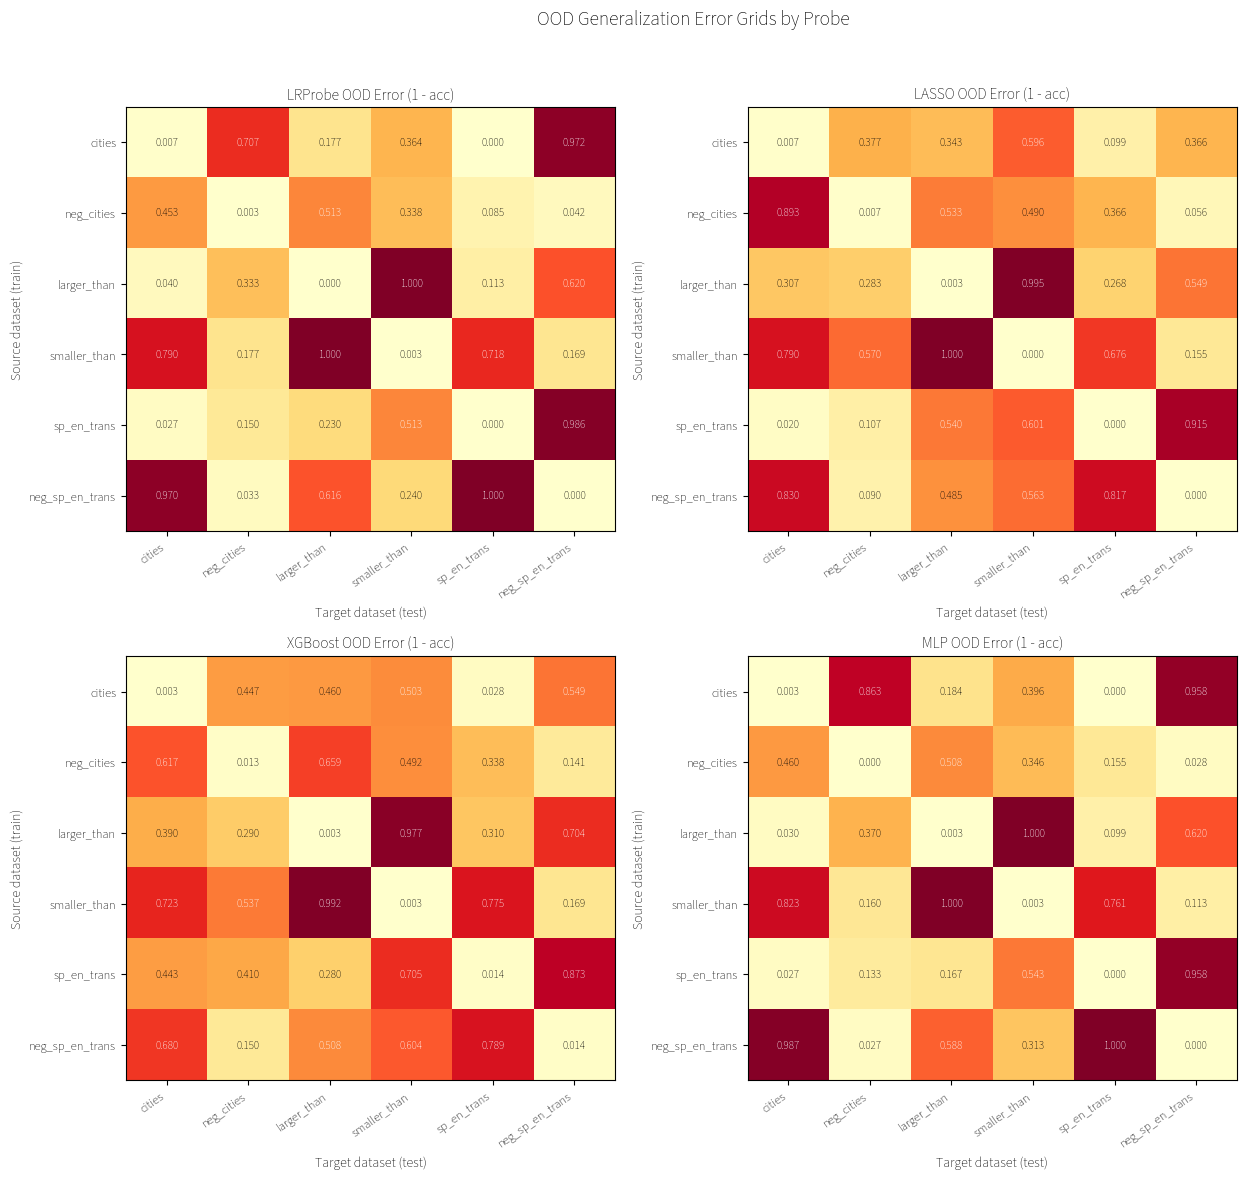

In [33]:
# Plot as heatmaps

probe_acc_mats = {
    'LRProbe': lr_ood_acc,
    'LASSO': lasso_ood_acc,
    'XGBoost': xgb_ood_acc,
    'MLP': mlp_ood_acc,
}
probe_err_mats = {k: 1.0 - v for k, v in probe_acc_mats.items()}

# Use fixed range [0, 1] so colorbar is consistent and readable
err_vmin, err_vmax = 0.0, 1.0

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, err_mat) in zip(axes, probe_err_mats.items()):
    im = ax.imshow(err_mat, cmap='YlOrRd', vmin=err_vmin, vmax=err_vmax, aspect='auto')

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(all_datasets, rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(all_datasets, fontsize=9)
    ax.set_xlabel('Target dataset (test)', fontsize=10)
    ax.set_ylabel('Source dataset (train)', fontsize=10)
    ax.set_title(f'{name} OOD Error (1 - acc)', fontsize=11)

    # Annotate each cell with error value
    for i in range(n):
        for j in range(n):
            val = err_mat[i, j]
            txt_color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, f"{val:.3f}", ha='center', va='center', color=txt_color, fontsize=8)

fig.suptitle('OOD Generalization Error Grids by Probe', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()